In [1]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append(os.path.abspath("../"))
from simulators.drossel_schwabl_CA import DrosselSchwablForestFire

from collections import Counter

# Simulation de la propagation d'un feu de forêt par le modèle de Drossel et Schwabl

In [2]:
def plot_forest(model, step=None):
    cmap = mcolors.ListedColormap(["white", "green", "orange"])
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    plt.figure(figsize=(6, 6))
    plt.imshow(model.grid, cmap=cmap, norm=norm)
    plt.axis("off")

    if step is not None:
        plt.title(f"Forêt au pas {step}")

    plt.show()

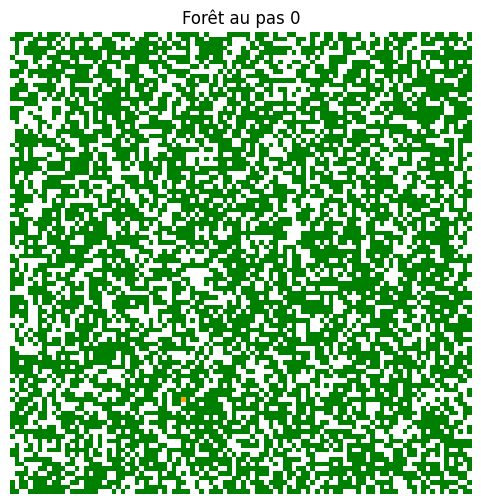

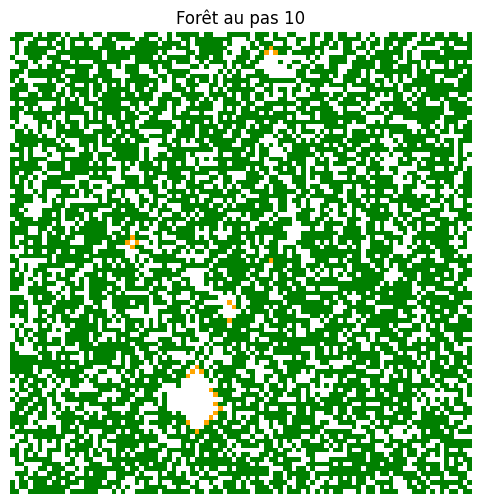

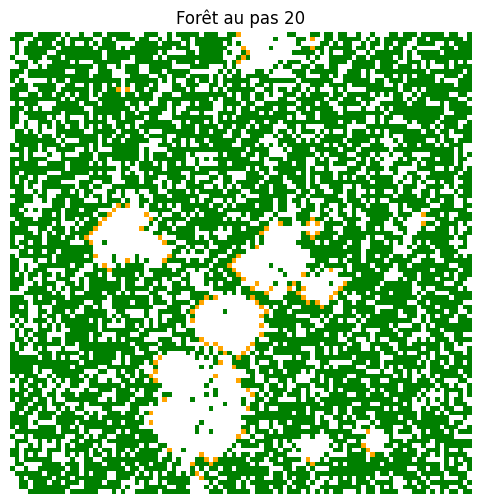

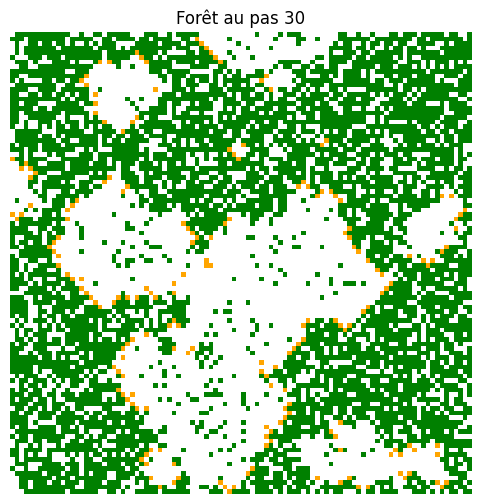

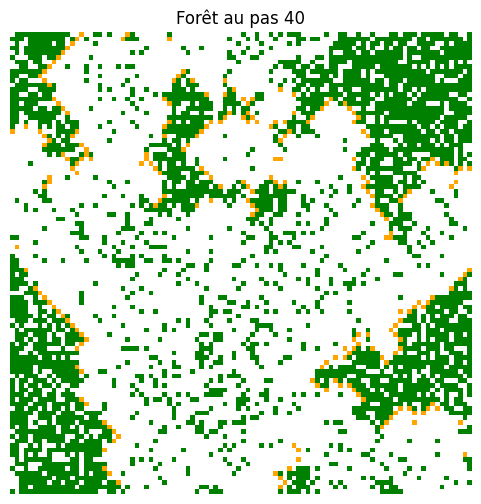

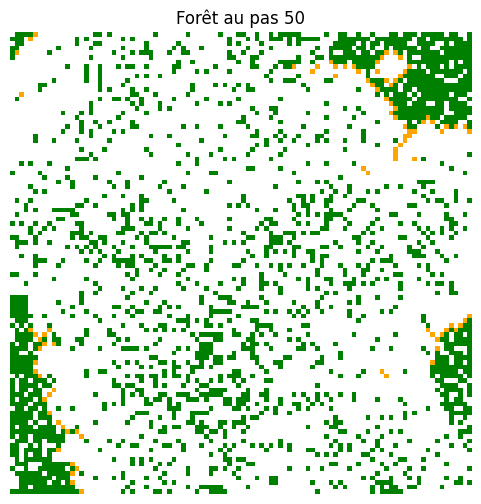

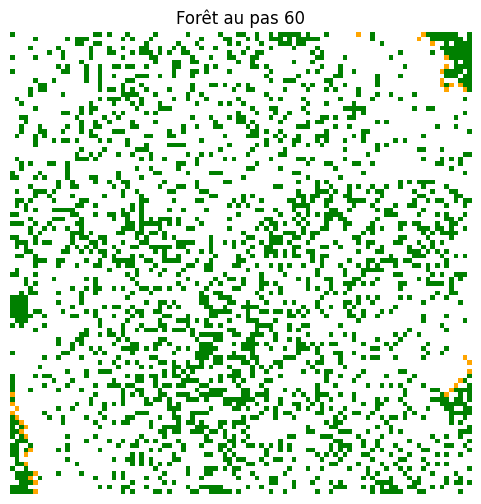

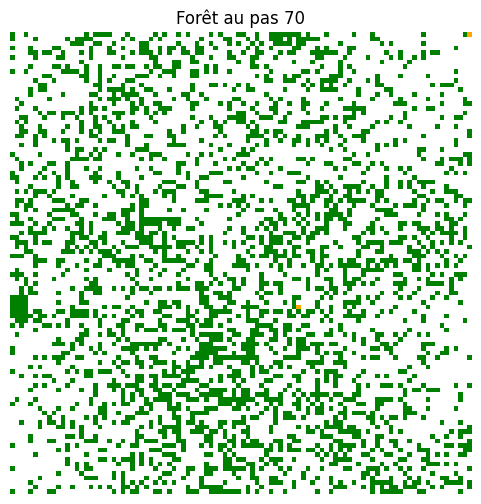

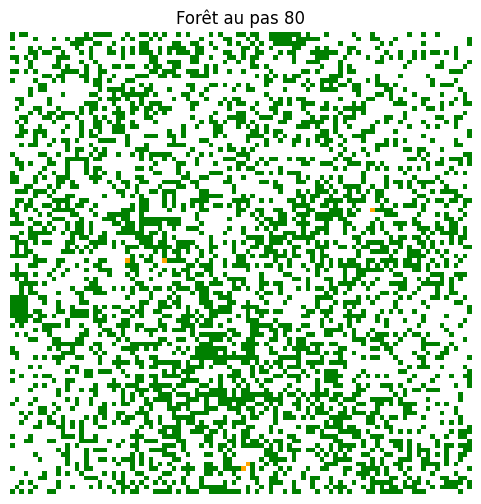

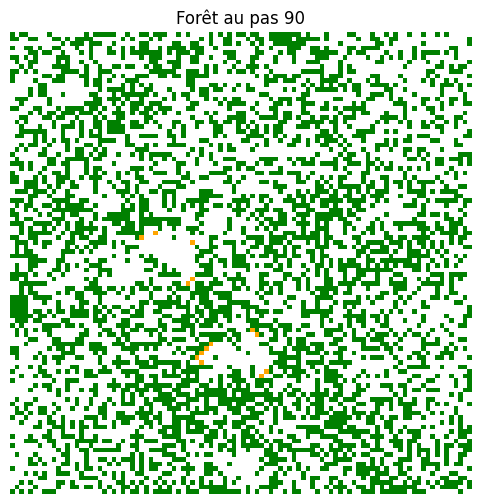

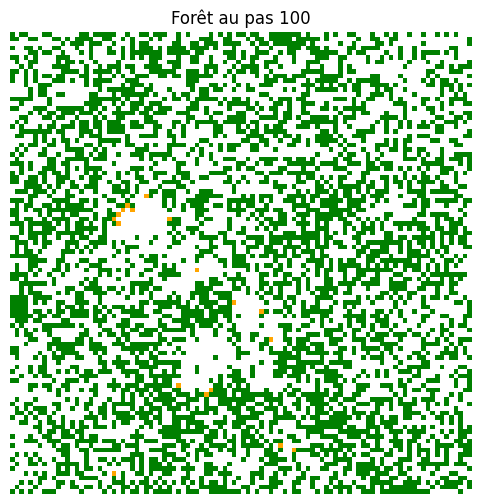

In [3]:
model = DrosselSchwablForestFire(
    width=100,
    height=100,
    p=0.01,          # pousse
    f=0.0001,        # foudre
    initial_tree_density=0.6
)

# On allume un arbre pour démarrer un feu 
model.ignite_random_tree()

n_steps = 100

for step in range(n_steps + 1):
    if step % 10 == 0:
        plot_forest(model, step)

    model.step()

# Densité d'arbres dans la forêt au cours du temps

In [4]:
def count_states(model):

    """Compte le nombre d'arbres vivants, d'arbres en feu et de cases vides."""
    trees = 0
    fires = 0
    empty = 0

    for row in model.grid:
        for cell in row:
            if cell == model.TREE:
                trees += 1
            elif cell == model.FIRE:
                fires += 1
            else:
                empty += 1

    return trees, fires, empty


def simulate_state_counts(model, n_steps=5000):
    """Simule le modèle pendant n_steps et enregistre le nombre d'arbres vivants, d'arbres en feu et de cases vides à chaque étape."""
    trees_series = []
    fires_series = []
    empty_series = []

    for _ in range(n_steps):
        trees, fires, empty = count_states(model)
        trees_series.append(trees)
        fires_series.append(fires)
        empty_series.append(empty)
        model.step()

    return trees_series, fires_series, empty_series




Simulation terminée pour p/f = 5
Simulation terminée pour p/f = 10
Simulation terminée pour p/f = 20
Simulation terminée pour p/f = 50


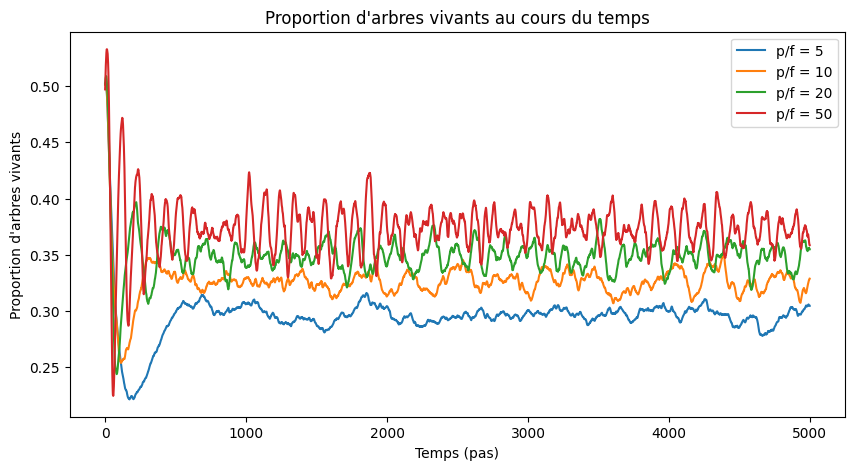

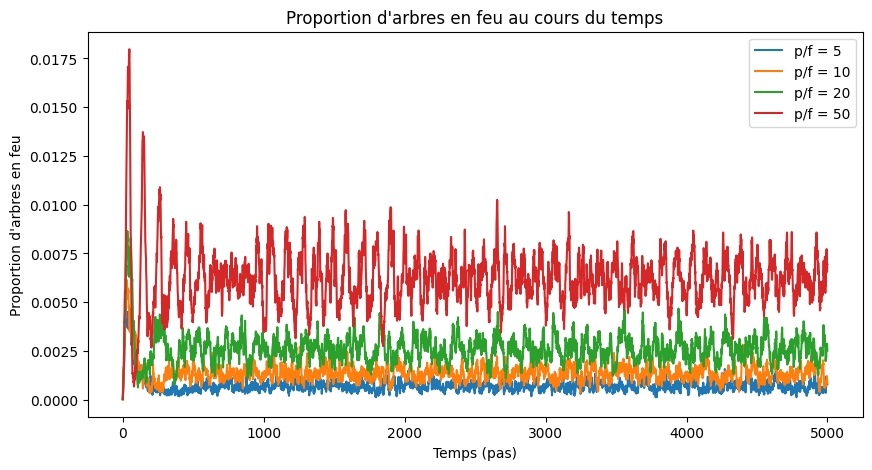

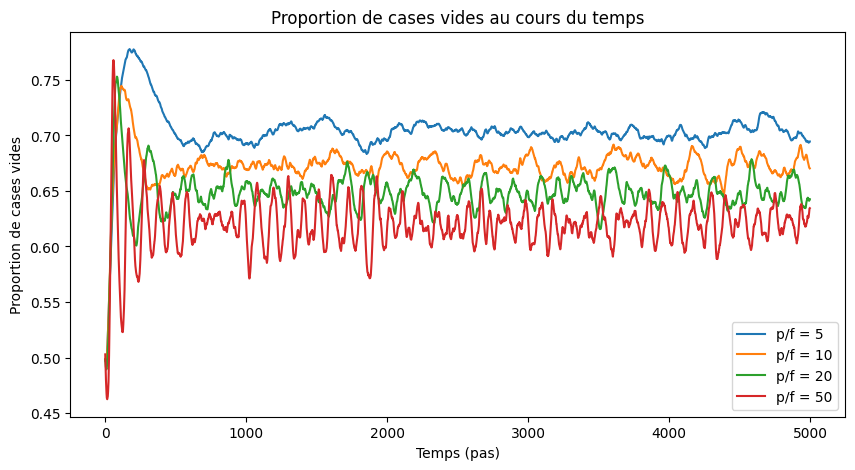

In [6]:
# Paramètres de la simulation
width = height = 200
f_fixed = 0.0002
ratios = [5, 10, 20, 50]
n_steps = 5000

results_states = {}

# On teste différents ratios p/f pour voir comment cela affecte la dynamique de la forêt
for ratio in ratios:
    p_value = ratio * f_fixed

    model = DrosselSchwablForestFire(
        width=width,
        height=height,
        p=p_value,
        f=f_fixed,
        initial_tree_density=0.5
    )

    model.ignite_random_tree()
    
    # On simule et enregistre les séries temporelles des états
    trees_series, fires_series, empty_series = simulate_state_counts(model, n_steps=n_steps)

    results_states[ratio] = {
        "trees": trees_series,
        "fires": fires_series,
        "empty": empty_series
    }

    print(f"Simulation terminée pour p/f = {ratio}")

total_cells = width * height

plt.figure(figsize=(10, 5))
for ratio in ratios:
    plt.plot(np.array(results_states[ratio]["trees"]) / total_cells, label=f"p/f = {ratio}")
plt.xlabel("Temps (pas)")
plt.ylabel("Proportion d'arbres vivants")
plt.title("Proportion d'arbres vivants au cours du temps")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for ratio in ratios:
    plt.plot(np.array(results_states[ratio]["fires"]) / total_cells, label=f"p/f = {ratio}")
plt.xlabel("Temps (pas)")
plt.ylabel("Proportion d'arbres en feu")
plt.title("Proportion d'arbres en feu au cours du temps")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for ratio in ratios:
    plt.plot(np.array(results_states[ratio]["empty"]) / total_cells, label=f"p/f = {ratio}")
plt.xlabel("Temps (pas)")
plt.ylabel("Proportion de cases vides")
plt.title("Proportion de cases vides au cours du temps")
plt.legend()
plt.show()

# Distribution de la taille des feux

In [8]:
def measure_fire_sizes_separated(model, n_steps=10000):
    """
    Mesure des tailles d'incendies en forçant une séparation nette des épisodes :
    - si aucun feu n'est actif, un arbre peut s'allumer spontanément avec la règle normale ;
    - dès qu'un feu est actif, on coupe temporairement la foudre ;
    - on mesure la taille totale jusqu'à extinction complète ;
    - ensuite seulement un nouvel épisode peut commencer.
    """
    fire_sizes = []

    original_f = model.f
    in_fire_event = False
    current_fire_size = 0

    for _ in range(n_steps):
        burning_now = model.count_burning()

        if burning_now > 0:
            in_fire_event = True
            current_fire_size += burning_now

            # Pendant un incendie, on empêche de nouveaux départs par foudre
            model.f = 0.0

        else:
            # Aucun feu actif
            model.f = original_f

            if in_fire_event:
                fire_sizes.append(current_fire_size)
                current_fire_size = 0
                in_fire_event = False

        model.step()

    if in_fire_event:
        fire_sizes.append(current_fire_size)

    model.f = original_f
    return fire_sizes


def cumulative_distribution(fire_sizes):
    """Calcule la distribution cumulative des tailles d'incendies."""
    sizes = np.array(sorted(fire_sizes))
    sizes = sizes[sizes > 0]
    x = np.unique(sizes)
    y = np.array([(sizes >= val).sum() for val in x])
    return x, y

Simulation pour p=0.001, f=0.0002, ratio p/f=5
  nombre de feux : 3810
  taille min/max : 1 2500

Simulation pour p=0.002, f=0.0002, ratio p/f=10
  nombre de feux : 2221
  taille min/max : 1 6597

Simulation pour p=0.004, f=0.0002, ratio p/f=20
  nombre de feux : 1167
  taille min/max : 1 29555



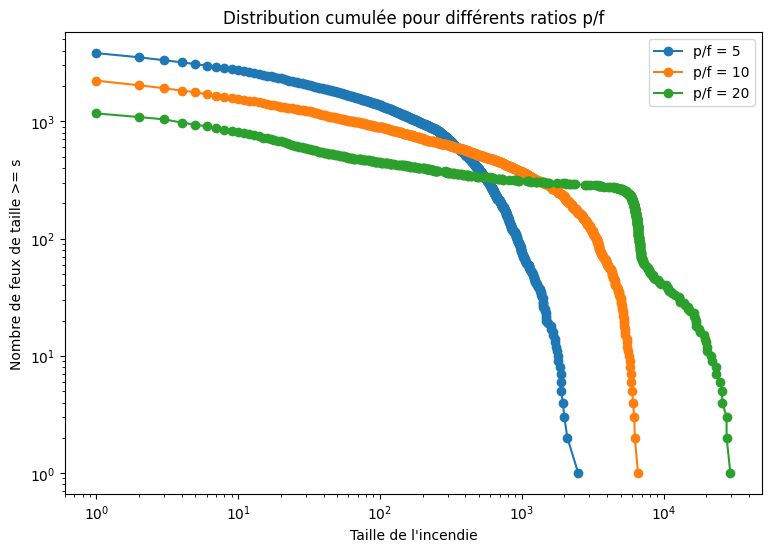

p/f =   5 | nb feux = 3810 | moyenne =     162.57 | médiane =      39.00 | max =       2500
p/f =  10 | nb feux = 2221 | moyenne =     539.45 | médiane =      42.00 | max =       6597
p/f =  20 | nb feux = 1167 | moyenne =    2003.29 | médiane =      30.00 | max =      29555


In [9]:
# On lance les simulations pour différents ratios p/f et on mesure les tailles d'incendies sur une grille 100*100 avec 100000 étapes.

width = height = 100
f_fixed = 0.0002
ratios = [5, 10, 20]
configs = [{"p": ratio * f_fixed, "f": f_fixed, "ratio": ratio} for ratio in ratios]

results = {}

for cfg in configs:
    print(f"Simulation pour p={cfg['p']}, f={cfg['f']}, ratio p/f={cfg['ratio']}")

    model = DrosselSchwablForestFire(
        width=width,
        height=height,
        p=cfg["p"],
        f=cfg["f"],
        initial_tree_density=0.5
    )

    model.ignite_random_tree()
    fire_sizes = measure_fire_sizes_separated(model, n_steps=100000)
    results[cfg["ratio"]] = fire_sizes

    print("  nombre de feux :", len(fire_sizes))
    if fire_sizes:
        print("  taille min/max :", min(fire_sizes), max(fire_sizes))
    print()

plt.figure(figsize=(9, 6))

for ratio, fire_sizes in results.items():
    if fire_sizes:
        x, y = cumulative_distribution(fire_sizes)
        plt.loglog(x, y, marker="o", linestyle="-", label=f"p/f = {ratio}")

plt.xlabel("Taille de l'incendie")
plt.ylabel("Nombre de feux de taille >= s")
plt.title("Distribution cumulée pour différents ratios p/f")
plt.legend()
plt.show()

for ratio, fire_sizes in results.items():
    if fire_sizes:
        print(
            f"p/f = {ratio:>3} | "
            f"nb feux = {len(fire_sizes):>4} | "
            f"moyenne = {np.mean(fire_sizes):>10.2f} | "
            f"médiane = {np.median(fire_sizes):>10.2f} | "
            f"max = {np.max(fire_sizes):>10}"
        )

Simulation pour p=0.001, f=0.0002, ratio p/f=5
  nombre de feux : 481
  taille min/max : 1 23759

Simulation pour p=0.002, f=0.0002, ratio p/f=10
  nombre de feux : 180
  taille min/max : 1 199668

Simulation pour p=0.004, f=0.0002, ratio p/f=20
  nombre de feux : 189
  taille min/max : 1 460035



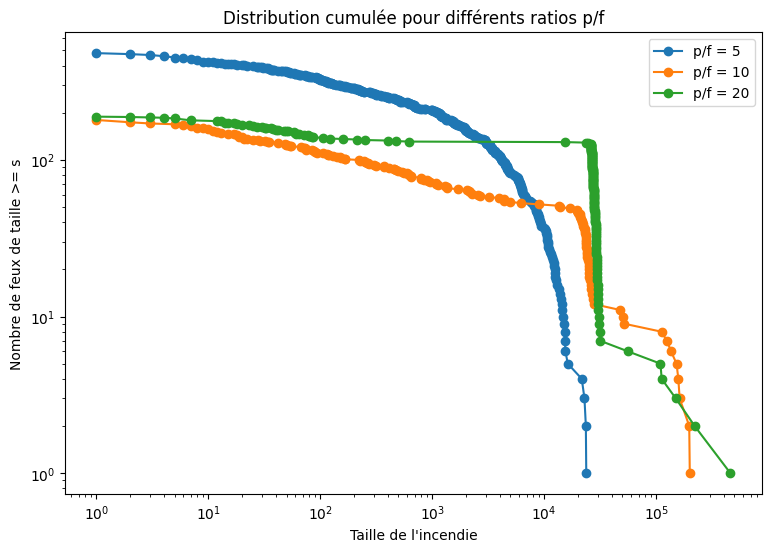

p/f =   5 | nb feux =  481 | moyenne =    2485.38 | médiane =     500.00 | max =      23759
p/f =  10 | nb feux =  180 | moyenne =   13246.77 | médiane =     368.50 | max =     199668
p/f =  20 | nb feux =  189 | moyenne =   24048.78 | médiane =   26922.00 | max =     460035


In [11]:
# On lance les simulations pour différents ratios p/f et on mesure les tailles d'incendies  pour une taille de grille 200*200 et 30000 étapes.
width = height = 200
f_fixed = 0.0002
ratios = [5, 10, 20]
configs = [{"p": ratio * f_fixed, "f": f_fixed, "ratio": ratio} for ratio in ratios]

results = {}

for cfg in configs:
    print(f"Simulation pour p={cfg['p']}, f={cfg['f']}, ratio p/f={cfg['ratio']}")

    model = DrosselSchwablForestFire(
        width=width,
        height=height,
        p=cfg["p"],
        f=cfg["f"],
        initial_tree_density=0.5
    )

    model.ignite_random_tree()
    fire_sizes = measure_fire_sizes_separated(model, n_steps=50000)
    results[cfg["ratio"]] = fire_sizes

    print("  nombre de feux :", len(fire_sizes))
    if fire_sizes:
        print("  taille min/max :", min(fire_sizes), max(fire_sizes))
    print()

plt.figure(figsize=(9, 6))

for ratio, fire_sizes in results.items():
    if fire_sizes:
        x, y = cumulative_distribution(fire_sizes)
        plt.loglog(x, y, marker="o", linestyle="-", label=f"p/f = {ratio}")

plt.xlabel("Taille de l'incendie")
plt.ylabel("Nombre de feux de taille >= s")
plt.title("Distribution cumulée pour différents ratios p/f")
plt.legend()
plt.show()

for ratio, fire_sizes in results.items():
    if fire_sizes:
        print(
            f"p/f = {ratio:>3} | "
            f"nb feux = {len(fire_sizes):>4} | "
            f"moyenne = {np.mean(fire_sizes):>10.2f} | "
            f"médiane = {np.median(fire_sizes):>10.2f} | "
            f"max = {np.max(fire_sizes):>10}"
        )